Инициализация среды

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


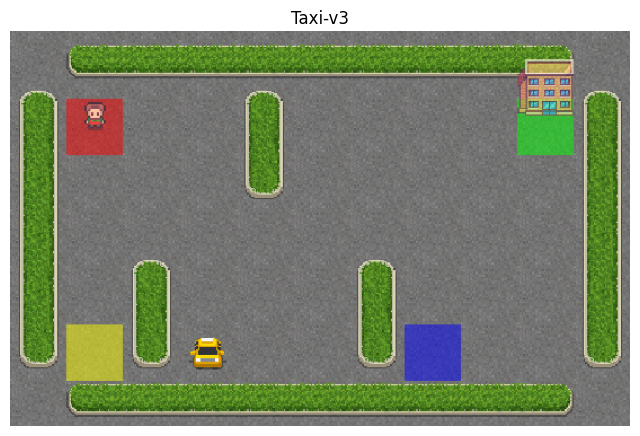

Кол-во состояний: 500, кол-во действий: 6


In [1]:
import sys, os
import pygame
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

frame = env.render()
plt.figure(figsize=(8, 6))
plt.imshow(frame)
plt.axis('off')
plt.title("Taxi-v3")
plt.show()

n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"Кол-во состояний: {n_states}, кол-во действий: {n_actions}")

Создание стохастической политики

In [2]:
def initialize_policy(n_states, n_actions):
    # равномерное распределение по всем действиям
    return np.full((n_states, n_actions), 1.0 / n_actions)

policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

Игра с моделью

In [3]:
def generate_session(env, policy, t_max=10**4):
    """
    Запускает одну игровую сессию до завершения или до t_max шагов.
    Возвращает списки состояний, действий и суммарную награду.
    """
    states, actions = [], []
    cumulative_reward = 0.0

    obs = env.reset()
    s = obs[0] if isinstance(obs, tuple) else obs

    for step in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])
        result = env.step(a)

        if len(result) == 5:
            new_s, r, terminated, truncated, info = result
            done = terminated or truncated
        else:
            new_s, r, done, info = result

        states.append(s)
        actions.append(a)
        cumulative_reward += r
        s = new_s

        if done:
            break

    return states, actions, cumulative_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

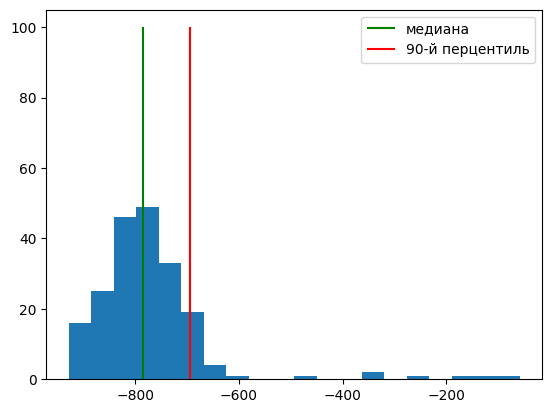

In [4]:
sample_rewards = [generate_session(env, policy, t_max=1000)[2] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="медиана", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90-й перцентиль", color='red')
plt.legend()
plt.show()

Шаги кросс-энтропийного метода

In [5]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Отбирает состояния и действия из сессий,
    у которых награда >= заданного процентиля.
    """
    threshold = np.percentile(rewards_batch, percentile)

    best_states, best_actions = [], []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= threshold:
            best_states += states
            best_actions += actions

    return best_states, best_actions

In [6]:
states_batch = [
    [1, 2, 3], # игра1
    [4, 2, 0, 2], # игра2
    [3, 1], # игра3
]
actions_batch = [
    [0, 2, 4], # игра1
    [3, 2, 0, 1], # игра2
    [3, 3], # игра3
]
rewards_batch = [
    3, # игра1
    4, # игра2
    5, # игра3
]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) \
and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]), \
"Для процентиля 0 вы должны вернуть все состояния и действия в хронологическом порядке."
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and \
np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]), \
"Для процентиля 30 вы должны выбрать состояния/действия только из двух первых"
assert np.all(test_result_90[0] == [3, 1]) and \
np.all(test_result_90[1] == [3, 3]), \
"Для процентиля 90 вы должны выбирать состояния/действия только из одной игры."
assert np.all(test_result_100[0] == [3, 1]) and\
np.all(test_result_100[1] == [3, 3]), \
"Убедитесь, что вы используете >=, а не >. Также дважды проверьте, как вы вычисляете процентиль."

In [7]:
def get_new_policy(elite_states, elite_actions):
    """
    По элитным состояниям/действиям строит новую политику.
    Вероятность действия пропорциональна частоте его появления.
    Для непосещённых состояний — равномерное распределение.
    """
    new_policy = np.zeros([n_states, n_actions])

    for state, action in zip(elite_states, elite_actions):
        new_policy[state][action] += 1

    for s in range(n_states):
        row_sum = new_policy[s].sum()
        if row_sum > 0:
            new_policy[s] /= row_sum
        else:
            new_policy[s] = np.ones(n_actions) / n_actions

    return new_policy

Тренировочный цикл

mean reward = -144.160, threshold = 5.500


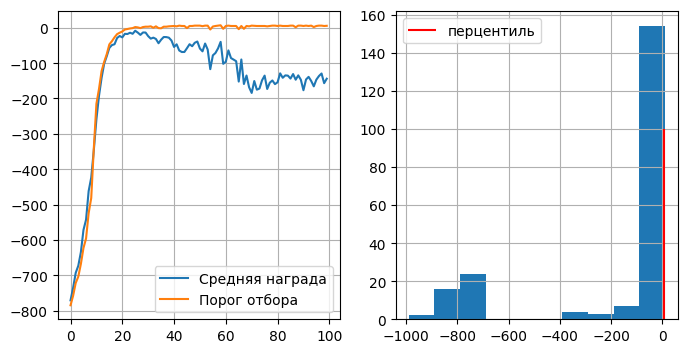

In [8]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_rew = np.mean(rewards_batch)
    thresh = np.percentile(rewards_batch, percentile)
    log.append([mean_rew, thresh])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Средняя награда')
    plt.plot(list(zip(*log))[1], label='Порог отбора')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([thresh], [0], [100], label="перцентиль", color='red')
    plt.legend()
    plt.grid()

    clear_output(True)
    print(f"mean reward = {mean_rew:.3f}, threshold = {thresh:.3f}")
    plt.show()

policy = initialize_policy(n_states, n_actions)

n_sessions = 250
percentile = 50
learning_rate = 0.5
log = []

for epoch in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    new_policy = get_new_policy(elite_states, elite_actions)

    # плавное обновление политики
    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    show_progress(rewards_batch, log, percentile)

Сходимость по задаче такси наступает примерно через 20 эпох, когда фиксируются почти максимальные показатели. При выходе на плато, когда большинство сессий завершается удачно, возникает трудность, связанная с фиксированным процентилем. В элиту отбираются сессии с наградой выше медианы, однако медиана в этой ситуации отражает усредненные по качеству траектории, а не наилучшие. В итоге политика обучения подстраивается под эти средние результаты, упуская из виду более перспективные варианты. Это приводит к падению средней награды до отметки -50/-100.